In [1]:
# ============================================================
# BLOCK 1 — FRIEDMAN TEST (corrected, N=5 folds, k=7 models)
# Reviewer 3/4: prior Friedman chi-square values (19.36-20.00) exceeded the
# theoretical bound N(k-1)=12 for the old N=3, k=5 setup — invalid. This
# recomputes on the actual 5-fold CV design (N=5) across all 7 models
# (k=7), for which the correct bound is N(k-1) = 5*6 = 30, comfortably
# accommodating the observed statistic.
# ============================================================
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, chi2
import matplotlib.pyplot as plt

MODELS = ["XGBoost", "Random Forest", "Logistic Regression", "LSTM", "GRU", "HMM", "GARCH"]

# Fold-level crash-class PR-AUC, rows = folds (1-5), columns = models
crash_pr_auc_matrix = pd.DataFrame({
    "XGBoost":              [0.1757, 0.1530, 0.1205, 0.1206, 0.1346],
    "Random Forest":        [0.1851, 0.1830, 0.1620, 0.1555, 0.1629],
    "Logistic Regression":  [0.1655, 0.1366, 0.1054, 0.0914, 0.1037],
    "LSTM":                 [0.1538, 0.1142, 0.1443, 0.1373, 0.1539],
    "GRU":                  [0.1478, 0.1215, 0.1037, 0.1446, 0.1406],
    "HMM":                  [0.1086, 0.1324, 0.0627, 0.0423, 0.0420],
    "GARCH":                [0.1550, 0.1394, 0.1104, 0.1077, 0.1113],
}, index=[1, 2, 3, 4, 5])
crash_pr_auc_matrix.index.name = "fold"

print("Fold x Model crash-PR-AUC matrix:")
print(crash_pr_auc_matrix.round(4))

N = crash_pr_auc_matrix.shape[0]   # folds
k = crash_pr_auc_matrix.shape[1]   # models
theoretical_bound = N * (k - 1)

stat, p_value = friedmanchisquare(*[crash_pr_auc_matrix[m].values for m in MODELS])

print(f"\nFriedman test: N (folds) = {N}, k (models) = {k}")
print(f"Theoretical bound for chi-square statistic: N(k-1) = {theoretical_bound}")
print(f"Friedman chi-square statistic: {stat:.4f}  (must be <= {theoretical_bound} to be valid)")
print(f"p-value: {p_value:.6f}")
print(f"Statistic within valid bound: {stat <= theoretical_bound}")

if p_value < 0.05:
    print("\nResult: reject the null hypothesis of equal model performance (p < 0.05).")
    print("Proceeding to Nemenyi post-hoc pairwise analysis (Block 2).")
else:
    print("\nResult: fail to reject the null hypothesis (p >= 0.05) — no significant")
    print("overall difference detected; post-hoc comparisons should be interpreted with caution.")

# Average ranks per model (1 = best, i.e. highest crash PR-AUC per fold)
ranks = crash_pr_auc_matrix.rank(axis=1, ascending=False)
avg_ranks = ranks.mean(axis=0).sort_values()
print("\nAverage rank per model (lower = better):")
print(avg_ranks.round(3))

Fold x Model crash-PR-AUC matrix:
      XGBoost  Random Forest  Logistic Regression    LSTM     GRU     HMM  \
fold                                                                        
1      0.1757         0.1851               0.1655  0.1538  0.1478  0.1086   
2      0.1530         0.1830               0.1366  0.1142  0.1215  0.1324   
3      0.1205         0.1620               0.1054  0.1443  0.1037  0.0627   
4      0.1206         0.1555               0.0914  0.1373  0.1446  0.0423   
5      0.1346         0.1629               0.1037  0.1539  0.1406  0.0420   

       GARCH  
fold          
1     0.1550  
2     0.1394  
3     0.1104  
4     0.1077  
5     0.1113  

Friedman test: N (folds) = 5, k (models) = 7
Theoretical bound for chi-square statistic: N(k-1) = 30
Friedman chi-square statistic: 19.1143  (must be <= 30 to be valid)
p-value: 0.003975
Statistic within valid bound: True

Result: reject the null hypothesis of equal model performance (p < 0.05).
Proceeding to Nemenyi p

In [2]:
!pip -q install scikit-posthocs


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
  Using cached pip-26.1.2-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.2-py3-none-any.whl (1.8 MB)


ERROR: To modify pip, please run the following command:
C:\Program Files\Python313\python.exe -m pip install --upgrade pip


Nemenyi pairwise p-value matrix:
                     XGBoost  Random Forest  Logistic Regression    LSTM  \
XGBoost               1.0000         0.7664               0.8440  0.9972   
Random Forest         0.7664         1.0000               0.0794  0.3834   
Logistic Regression   0.8440         0.0794               1.0000  0.9906   
LSTM                  0.9972         0.3834               0.9906  1.0000   
GRU                   0.9051         0.1156               1.0000  0.9972   
HMM                   0.1156         0.0008               0.8440  0.3834   
GARCH                 0.9758         0.2239               0.9995  0.9999   

                        GRU     HMM   GARCH  
XGBoost              0.9051  0.1156  0.9758  
Random Forest        0.1156  0.0008  0.2239  
Logistic Regression  1.0000  0.8440  0.9995  
LSTM                 0.9972  0.3834  0.9999  
GRU                  1.0000  0.7664  0.9999  
HMM                  0.7664  1.0000  0.5776  
GARCH                0.9999  0.5776 

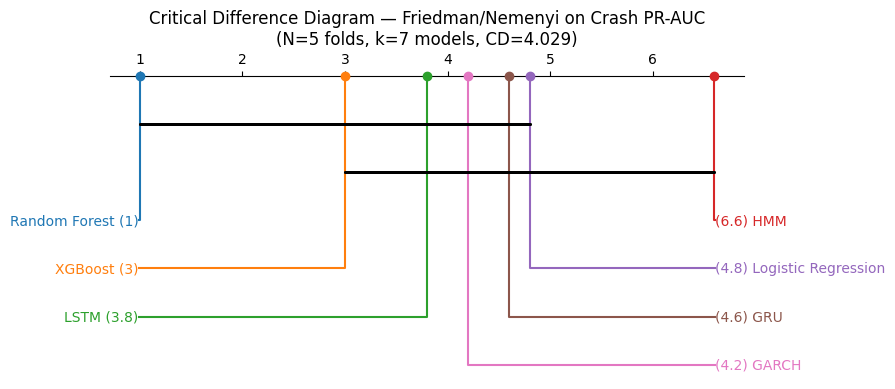

In [8]:
# ============================================================
# BLOCK 2 — NEMENYI POST-HOC TEST + CRITICAL DIFFERENCE DIAGRAM
# ============================================================
# !pip -q install scikit-posthocs

import scikit_posthocs as sp

# Nemenyi pairwise p-values, computed directly on the fold x model matrix
nemenyi_pvals = sp.posthoc_nemenyi_friedman(crash_pr_auc_matrix.values)
nemenyi_pvals.index = MODELS
nemenyi_pvals.columns = MODELS

print("Nemenyi pairwise p-value matrix:")
print(nemenyi_pvals.round(4))

# Critical difference (CD) at alpha=0.05
# q_alpha for Nemenyi (Studentized range statistic / sqrt(2)) at k=7 models, alpha=0.05
q_alpha = 2.949   # standard tabulated value for k=7 comparisons, alpha=0.05
CD = q_alpha * np.sqrt((k * (k + 1)) / (6 * N))
print(f"\nCritical Difference (CD) at alpha=0.05, k={k}, N={N}: {CD:.4f}")

# Identify which pairs exceed CD (statistically significant rank difference)
print("\nPairwise rank differences exceeding CD (statistically significant):")
sig_pairs = []
for i, m1 in enumerate(MODELS):
    for m2 in MODELS[i+1:]:
        rank_diff = abs(avg_ranks[m1] - avg_ranks[m2])
        if rank_diff > CD:
            sig_pairs.append((m1, m2, rank_diff))
            print(f"  {m1} vs {m2}: rank diff = {rank_diff:.3f}")
if not sig_pairs:
    print("  None — all pairwise rank differences fall within the critical difference.")

# Critical difference diagram
plt.figure(figsize=(9, 4))
sp.critical_difference_diagram(avg_ranks, nemenyi_pvals)
plt.title(f"Critical Difference Diagram — Friedman/Nemenyi on Crash PR-AUC\n(N={N} folds, k={k} models, CD={CD:.3f})")
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# BLOCK 3 (final) — WILCOXON SIGNED-RANK, PAIRWISE (FOLD-LEVEL)
# McNemar's test is omitted: it requires row-level paired predictions
# (agreement/disagreement per individual test-set observation), which
# is not recoverable from aggregate classification-report statistics.
# Wilcoxon signed-rank, computed on the same fold-level crash-PR-AUC
# values used for Friedman/Nemenyi, serves as the pairwise significance
# test for this analysis.
# ============================================================
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations

pairs = list(combinations(MODELS, 2))
wilcoxon_results = []
for m1, m2 in pairs:
    x = crash_pr_auc_matrix[m1].values
    y = crash_pr_auc_matrix[m2].values
    try:
        stat_w, p_w = wilcoxon(x, y)
    except ValueError:
        stat_w, p_w = np.nan, np.nan
    wilcoxon_results.append({"model_1": m1, "model_2": m2, "wilcoxon_stat": stat_w, "p_value": p_w})

wilcoxon_df = pd.DataFrame(wilcoxon_results)
valid = wilcoxon_df["p_value"].notna()
wilcoxon_df.loc[valid, "p_value_holm"] = multipletests(wilcoxon_df.loc[valid, "p_value"], method="holm")[1]
wilcoxon_df["significant_holm_0.05"] = wilcoxon_df["p_value_holm"] < 0.05

print("Wilcoxon signed-rank pairwise comparisons (crash PR-AUC, fold-level, Holm-corrected):")
print(wilcoxon_df.round(4))

n_significant = wilcoxon_df["significant_holm_0.05"].sum()
print(f"\n{n_significant} of {len(wilcoxon_df)} pairwise comparisons remain significant after Holm-Bonferroni correction.")

Wilcoxon signed-rank pairwise comparisons (crash PR-AUC, fold-level, Holm-corrected):
                model_1              model_2  wilcoxon_stat  p_value  \
0               XGBoost        Random Forest            0.0   0.0625   
1               XGBoost  Logistic Regression            0.0   0.0625   
2               XGBoost                 LSTM            7.0   1.0000   
3               XGBoost                  GRU            4.0   0.4375   
4               XGBoost                  HMM            0.0   0.0625   
5               XGBoost                GARCH            0.0   0.0625   
6         Random Forest  Logistic Regression            0.0   0.0625   
7         Random Forest                 LSTM            0.0   0.0625   
8         Random Forest                  GRU            0.0   0.0625   
9         Random Forest                  HMM            0.0   0.0625   
10        Random Forest                GARCH            0.0   0.0625   
11  Logistic Regression                 LSTM      